# Module 6: Regression Analysis

### Course: R Programming - A Comprehensive Guide

**Author:** Kajola Gbenga
**Role:** Data Scientist & AI Engineer

---


## Learning Objectives

By the end of this notebook, you will be able to:

- Build and interpret simple linear regression models
- Build and interpret multiple linear regression models
- Build and interpret logistic regression models
- Understand the process of model building and interpretation
- Check regression model assumptions
- Run diagnostic tests on fitted models
- Evaluate model performance using appropriate metrics

## 1. Simple Linear Regression

Simple linear regression models the relationship between one predictor (independent variable) and one continuous outcome (dependent variable) using the equation:

`Y = b0 + b1*X + error`

In R, the `lm()` function fits linear models.


Call:
lm(formula = mpg ~ wt, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.5432 -2.3647 -0.1252  1.4096  6.8727 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  37.2851     1.8776  19.858  < 2e-16 ***
wt           -5.3445     0.5591  -9.559 1.29e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.046 on 30 degrees of freedom
Multiple R-squared:  0.7528,	Adjusted R-squared:  0.7446 
F-statistic: 91.38 on 1 and 30 DF,  p-value: 1.294e-10


Warning message:
"package 'ggplot2' was built under R version 4.5.3"
`geom_smooth()` using formula = 'y ~ x'


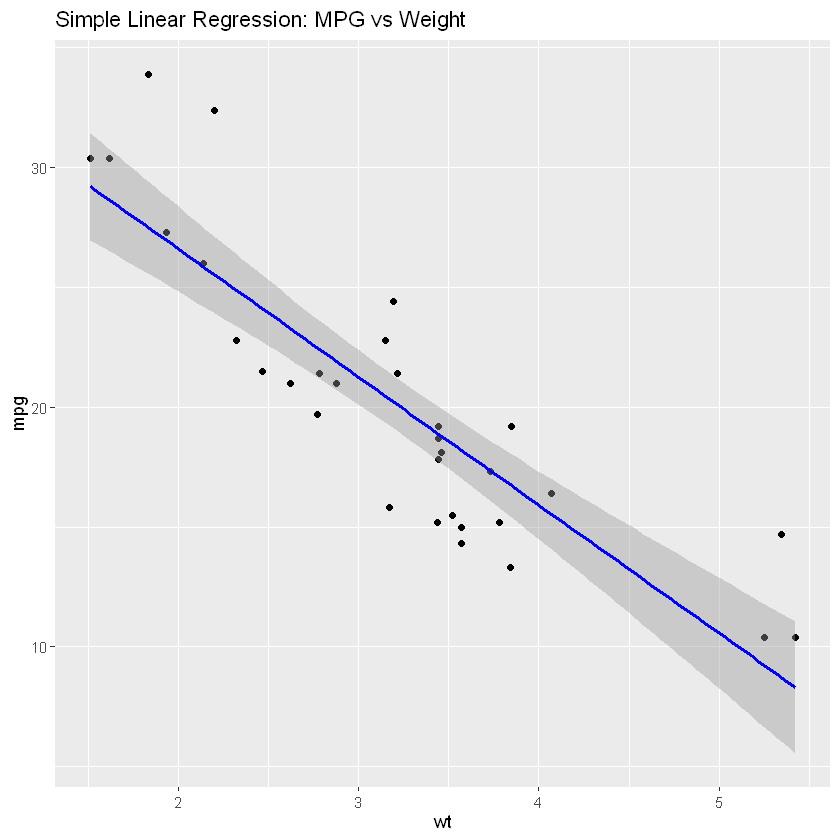

In [1]:
data(mtcars)

model_simple <- lm(mpg ~ wt, data = mtcars)
summary(model_simple)

library(ggplot2)
ggplot(mtcars, aes(x = wt, y = mpg)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(title = "Simple Linear Regression: MPG vs Weight")


## 2. Multiple Linear Regression

Multiple linear regression extends simple regression to include several predictors:

`Y = b0 + b1*X1 + b2*X2 + ... + bn*Xn + error`


In [2]:
model_multiple <- lm(mpg ~ wt + hp + disp, data = mtcars)
summary(model_multiple)

# Comparing models with anova()
anova(model_simple, model_multiple)



Call:
lm(formula = mpg ~ wt + hp + disp, data = mtcars)

Residuals:
   Min     1Q Median     3Q    Max 
-3.891 -1.640 -0.172  1.061  5.861 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 37.105505   2.110815  17.579  < 2e-16 ***
wt          -3.800891   1.066191  -3.565  0.00133 ** 
hp          -0.031157   0.011436  -2.724  0.01097 *  
disp        -0.000937   0.010350  -0.091  0.92851    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.639 on 28 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8083 
F-statistic: 44.57 on 3 and 28 DF,  p-value: 8.65e-11


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,30,278.3219,NA,NA,NA,NA
2,28,194.9907,2,83.33126,5.983043,0.006863247


## 3. Logistic Regression

Logistic regression is used when the outcome variable is binary (e.g. 0/1, Yes/No). It models the log-odds of the outcome as a linear function of the predictors, fit in R using `glm()` with `family = binomial`.

In [3]:
# Using mtcars' 'am' variable (0 = automatic, 1 = manual) as a binary outcome
model_logistic <- glm(am ~ wt + hp, data = mtcars, family = binomial)
summary(model_logistic)

# Predicted probabilities
predicted_probs <- predict(model_logistic, type = "response")
head(predicted_probs)

# Converting probabilities to class predictions
predicted_class <- ifelse(predicted_probs > 0.5, 1, 0)
table(Predicted = predicted_class, Actual = mtcars$am)



Call:
glm(formula = am ~ wt + hp, family = binomial, data = mtcars)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept) 18.86630    7.44356   2.535  0.01126 * 
wt          -8.08348    3.06868  -2.634  0.00843 **
hp           0.03626    0.01773   2.044  0.04091 * 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.230  on 31  degrees of freedom
Residual deviance: 10.059  on 29  degrees of freedom
AIC: 16.059

Number of Fisher Scoring iterations: 8


Mazda RX4     Mazda RX4 Wag        Datsun 710    Hornet 4 Drive 
      0.842335537       0.404782533       0.970240822       0.041728035 
Hornet Sportabout           Valiant 
      0.069388122       0.004988159

         Actual
Predicted  0  1
        0 18  1
        1  1 12

## 4. Model Building and Interpretation

A typical model building workflow:
1. Explore the data and check relationships (correlation, scatterplots)
2. Fit an initial model with candidate predictors
3. Check statistical significance of coefficients (p-values)
4. Refine the model by removing non-significant predictors or adding interactions
5. Validate assumptions and evaluate performance

**Interpreting coefficients:**
- In linear regression, a coefficient represents the expected change in Y for a one unit increase in X, holding other variables constant
- In logistic regression, `exp(coefficient)` gives the odds ratio


In [4]:
# Stepwise model selection based on AIC
full_model <- lm(mpg ~ wt + hp + disp + cyl + qsec, data = mtcars)
step_model <- step(full_model, direction = "both", trace = FALSE)
summary(step_model)

# Odds ratios for the logistic regression model
exp(coef(model_logistic))



Call:
lm(formula = mpg ~ wt + hp + cyl, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9290 -1.5598 -0.5311  1.1850  5.8986 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 38.75179    1.78686  21.687  < 2e-16 ***
wt          -3.16697    0.74058  -4.276 0.000199 ***
hp          -0.01804    0.01188  -1.519 0.140015    
cyl         -0.94162    0.55092  -1.709 0.098480 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.512 on 28 degrees of freedom
Multiple R-squared:  0.8431,	Adjusted R-squared:  0.8263 
F-statistic: 50.17 on 3 and 28 DF,  p-value: 2.184e-11


(Intercept)           wt           hp 
1.561455e+08 3.085967e-04 1.036921e+00

## 5. Model Assumptions

Linear regression relies on several key assumptions:
- **Linearity**: relationship between predictors and outcome is linear
- **Independence**: residuals are independent of each other
- **Homoscedasticity**: residuals have constant variance
- **Normality**: residuals are approximately normally distributed
- **No multicollinearity**: predictors are not too highly correlated with each other


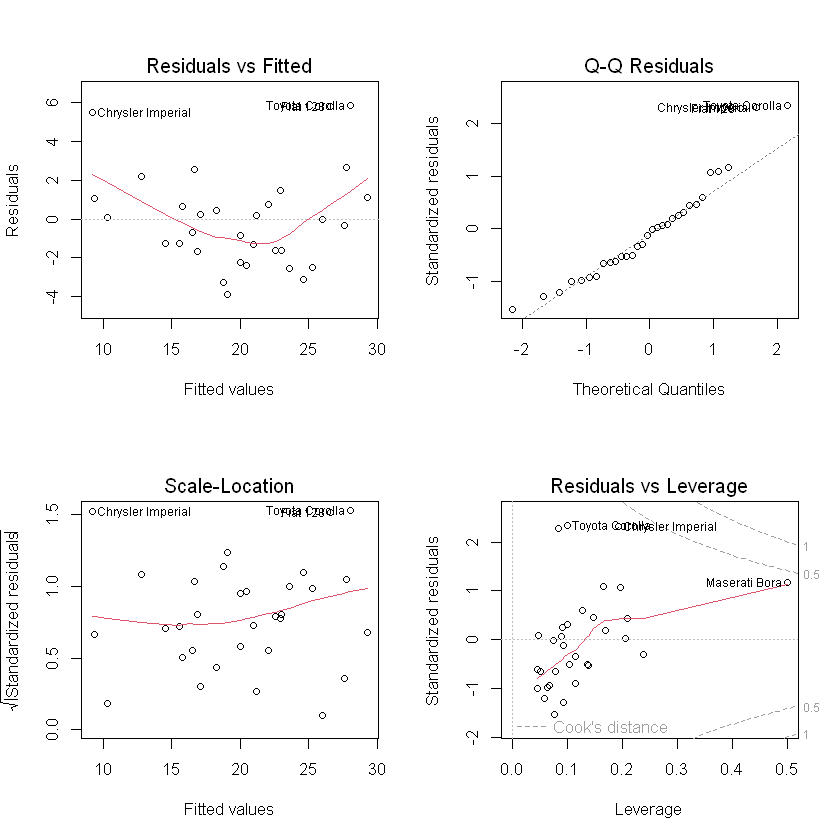

In [5]:
# Diagnostic plots check the assumptions visually
par(mfrow = c(2, 2))
plot(model_multiple)
par(mfrow = c(1, 1))


## 6. Diagnostic Tests

Beyond visual diagnostics, formal statistical tests can confirm whether assumptions hold.

In [6]:
# install.packages("car") # if not already installed
library(car)

# Multicollinearity check - Variance Inflation Factor (VIF)
# Rule of thumb: VIF > 5 or 10 suggests problematic multicollinearity
vif(model_multiple)

# Homoscedasticity check - Breusch-Pagan test
ncvTest(model_multiple)

# Normality of residuals - Shapiro-Wilk test
shapiro.test(residuals(model_multiple))


Warning message:
"package 'car' was built under R version 4.5.3"
Loading required package: carData

Warning message:
"package 'carData' was built under R version 4.5.3"


wt       hp     disp 
4.844618 2.736633 7.324517

Non-constant Variance Score Test 
Variance formula: ~ fitted.values 
Chisquare = 0.7454713, Df = 1, p = 0.38791


	Shapiro-Wilk normality test

data:  residuals(model_multiple)
W = 0.92734, p-value = 0.03305


## 7. Model Evaluation and Performance Metrics

**For regression models:**
- R-squared and Adjusted R-squared - proportion of variance explained
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)

**For classification models:**
- Accuracy, Precision, Recall, F1-score
- Confusion matrix
- ROC curve and AUC


RMSE: 2.468493 
MAE: 1.907026 
R-squared: 0.8268361 
Accuracy: 0.9375 


Warning message:
"package 'pROC' was built under R version 4.5.3"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.9838

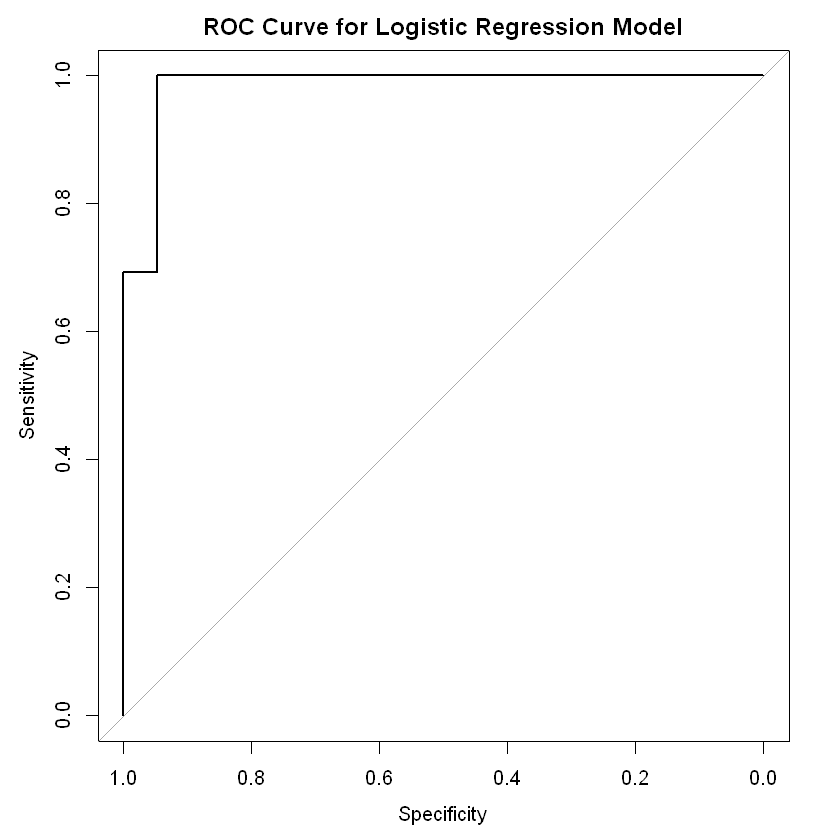

In [7]:
# ---- Regression metrics ----
predicted <- predict(model_multiple)
actual <- mtcars$mpg

rmse <- sqrt(mean((actual - predicted)^2))
mae <- mean(abs(actual - predicted))
r_squared <- summary(model_multiple)$r.squared

cat("RMSE:", rmse, "\nMAE:", mae, "\nR-squared:", r_squared, "\n")

# ---- Classification metrics ----
conf_matrix <- table(Predicted = predicted_class, Actual = mtcars$am)
accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)
cat("Accuracy:", accuracy, "\n")

# ROC curve and AUC
# install.packages("pROC")
library(pROC)
roc_obj <- roc(mtcars$am, predicted_probs)
plot(roc_obj, main = "ROC Curve for Logistic Regression Model")
auc(roc_obj)


## Practice Exercise

1. Fit a simple linear regression model on a data set of your choice and interpret the slope coefficient.
2. Build a multiple linear regression model, check VIF for multicollinearity, and refine the model if needed.
3. Fit a logistic regression model on a binary outcome and report the accuracy of your predictions.
4. Produce and interpret the four standard diagnostic plots for one of your fitted models.


---

## Module Summary

This notebook has walked through the core concepts, R code demonstrations, and practice exercises for this module. Review each section, run every code cell yourself, and attempt the practice exercises before moving to the next module.

**Kajola Gbenga**
Data Scientist & AI Engineer